### imports & directories

In [2]:
import numpy as np
import pandas as pd
import multiprocessing as mp
from pathlib import Path

import analysis.plot as plot
from analysis.locking_map import run_constant_locking_map, run_sinusoidal_locking_map 

ROOT = Path.cwd().parent
FIG_DIR = ROOT / "fig/phase_locking_analysis"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = ROOT / "results/phase_locking_analysis"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

### parameters

In [2]:
T = 30
TRANSIENT = 1

NEURON_A_PARAMS = dict(
    name = "neuron A",
    V_th = 0.01
)

NEURON_B_PARAMS = dict(
    name = "neuron B"
)

SYN_EXC_PARAMS = dict(
    w=0.05,
    tau_syn=0.05
)

SYN_INH_0_PARAMS = dict(
    w=0, 
    tau_syn=0
)

SYN_INH_PARAMS = dict(
    w=0.7, 
    tau_syn=0.07
)

N_WORKERS = max(1, mp.cpu_count() - 1)

I0_values = np.linspace(0.1, 1.0, 20)
f_values = np.linspace(1.0, 10.0, 20)

# Sinusoidal current and neuron A phase locking

### open-loop

In [ ]:
df_sin_open = run_sinusoidal_locking_map(
    I0_values,
    f_values,
    T,
    TRANSIENT,
    NEURON_A_PARAMS, 
    NEURON_B_PARAMS,
    SYN_EXC_PARAMS, 
    SYN_INH_0_PARAMS,
    N_WORKERS
)
df_sin_open.to_csv(RESULTS_DIR / "sin_open.csv", index=False)

In [3]:
df_sin_open = pd.read_csv(RESULTS_DIR / "sin_open.csv")

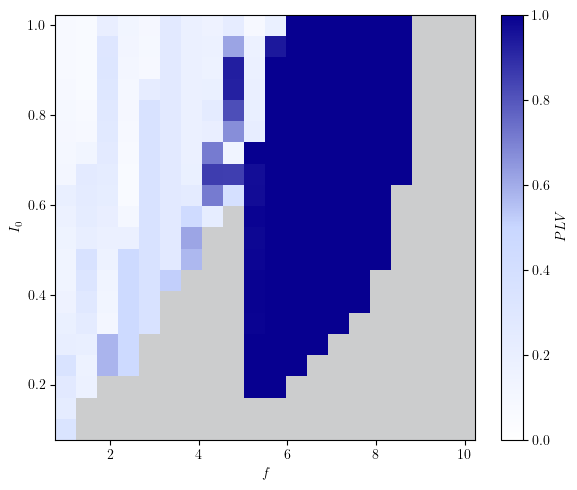

In [4]:
fig = plot.plv_locking_map(df_sin_open, "plv_11_A", cbar_label="$PLV$", T_mask=0.8*T)

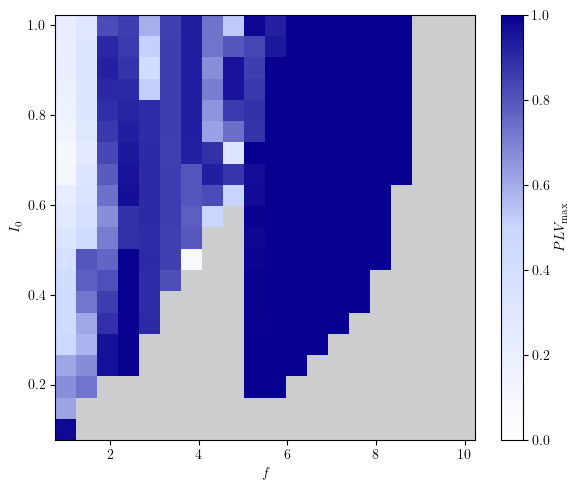

In [5]:
fig = plot.plv_locking_map(df_sin_open, "plv_nm_A", cbar_label=r"$PLV_\mathrm{max}$", T_mask=0.8*T)

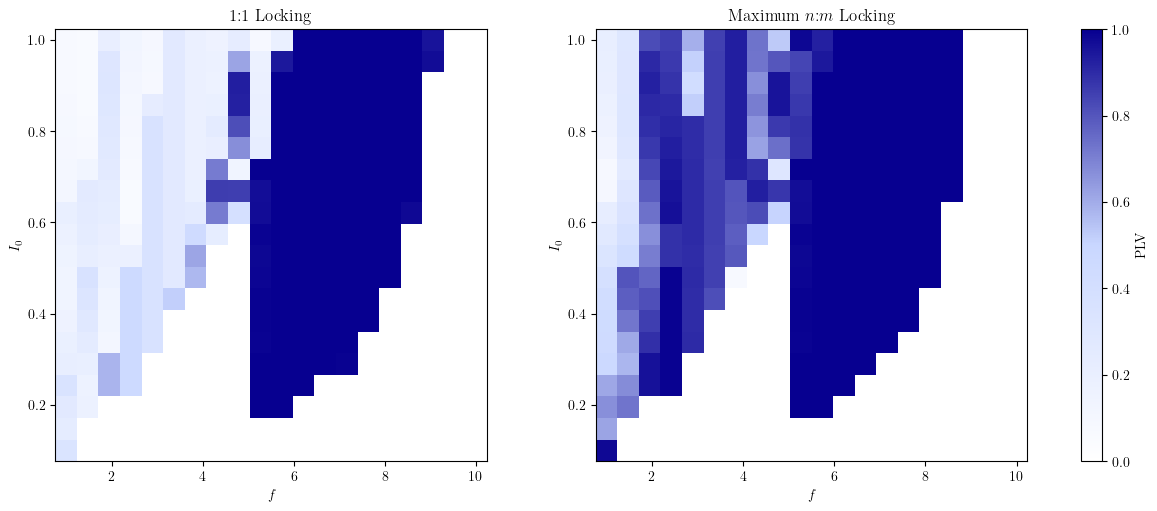

In [6]:
fig = plot.plv_locking_map_side_by_side(df_sin_open, df_sin_open, "plv_11_A", "plv_nm_A", title1=r"$1{:}1$ Locking",title2=r"Maximum $n{:}m$ Locking")
fig.savefig(FIG_DIR / "locking_open_11_vs_m1.pdf", bbox_inches="tight")

### closed loop

In [ ]:
df_sin_closed = run_sinusoidal_locking_map(
    I0_values,
    f_values,
    T,
    TRANSIENT,
    NEURON_A_PARAMS, 
    NEURON_B_PARAMS,
    SYN_EXC_PARAMS, 
    SYN_INH_PARAMS,
    N_WORKERS
)
df_sin_closed.to_csv(RESULTS_DIR / "sin_closed.csv", index=False)

In [7]:
df_sin_closed = pd.read_csv(RESULTS_DIR / "sin_closed.csv")

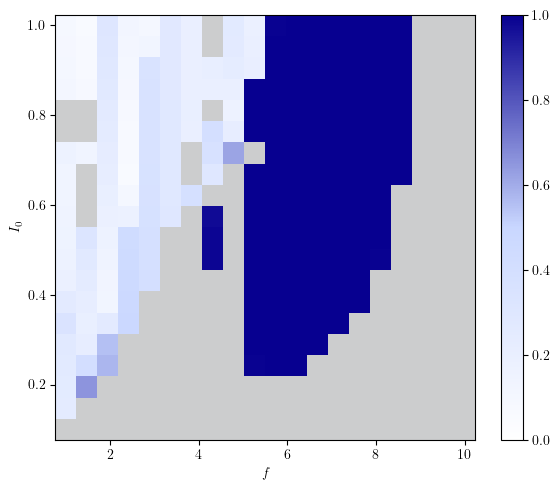

In [8]:
fig = plot.plv_locking_map(df_sin_closed, "plv_11_A", T_mask=0.8*T)

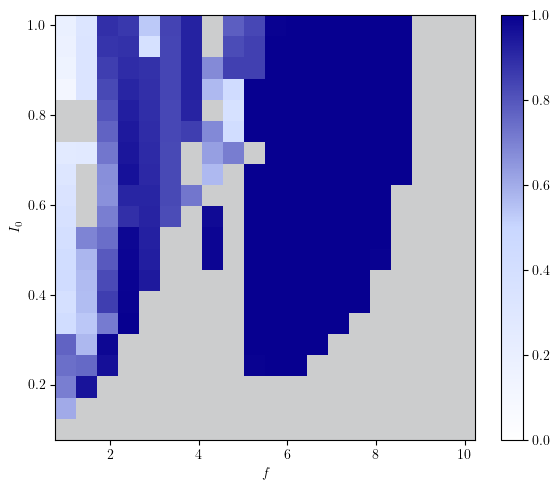

In [9]:
fig = plot.plv_locking_map(df_sin_closed, "plv_nm_A", T_mask=0.8*T)

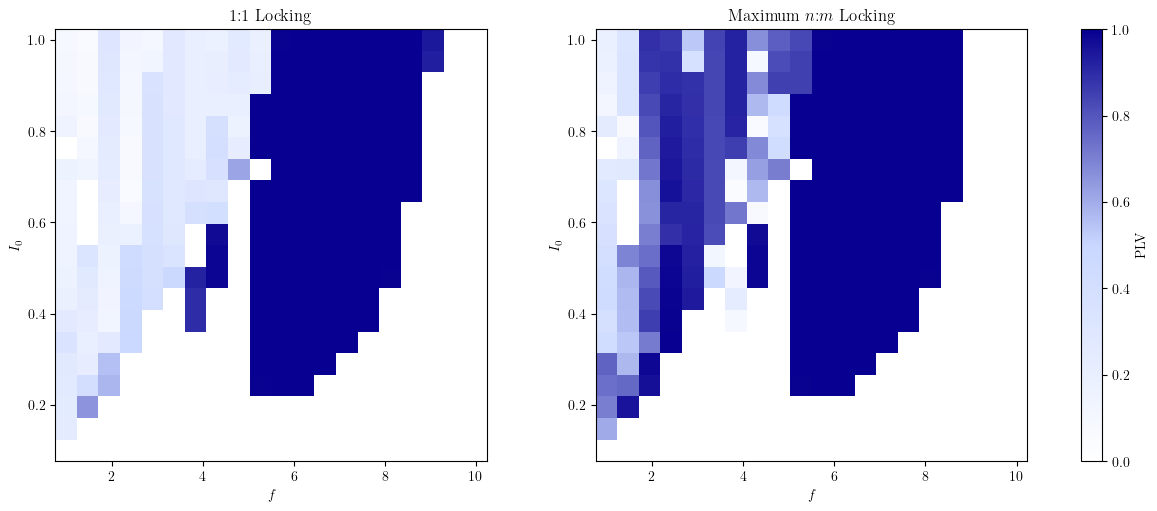

In [10]:
fig = plot.plv_locking_map_side_by_side(df_sin_closed, df_sin_closed, "plv_11_A", "plv_nm_A", title1=r"$1{:}1$ Locking", title2=r"Maximum $n{:}m$ Locking")
fig.savefig(FIG_DIR / "locking_closed_11_vs_m1.pdf", bbox_inches="tight")

### closed vs open loop

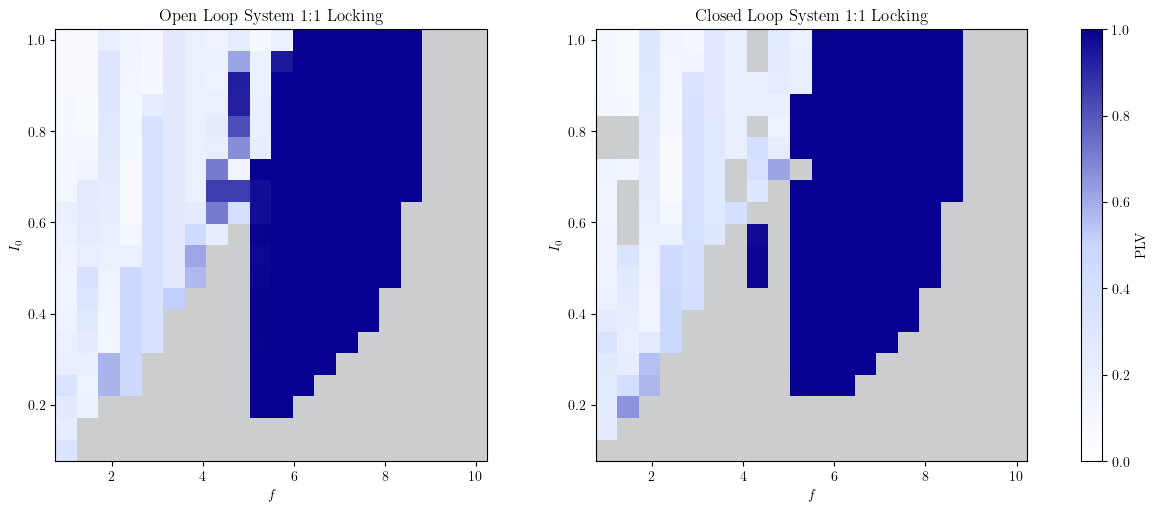

In [11]:
fig = plot.plv_locking_map_side_by_side(df_sin_open, df_sin_closed, "plv_11_A", "plv_11_A", title1=r"Open Loop System $1{:}1$ Locking", title2=r"Closed Loop System $1{:}1$ Locking", T_mask=0.8*T)
fig.savefig(FIG_DIR / "locking_open_vs_closed_11.pdf", bbox_inches="tight")

# Neuron A under constant current

In [ ]:
df_const_open = run_constant_locking_map(I0_values, T, TRANSIENT, NEURON_A_PARAMS, NEURON_B_PARAMS, SYN_EXC_PARAMS, SYN_INH_0_PARAMS, N_WORKERS)
df_const_closed = run_constant_locking_map(I0_values, T, TRANSIENT, NEURON_A_PARAMS, NEURON_B_PARAMS, SYN_EXC_PARAMS, SYN_INH_PARAMS, N_WORKERS)

df_const_open.to_csv(RESULTS_DIR/"const_open.csv", index=False)
df_const_closed.to_csv(RESULTS_DIR/"const_closed.csv", index=False)

# Constant and sinusoidal input current comparison for an open loop system

In [3]:
df_sin_open = pd.read_csv(RESULTS_DIR / "sin_open.csv")
df_const_open = pd.read_csv(RESULTS_DIR / "const_open.csv")

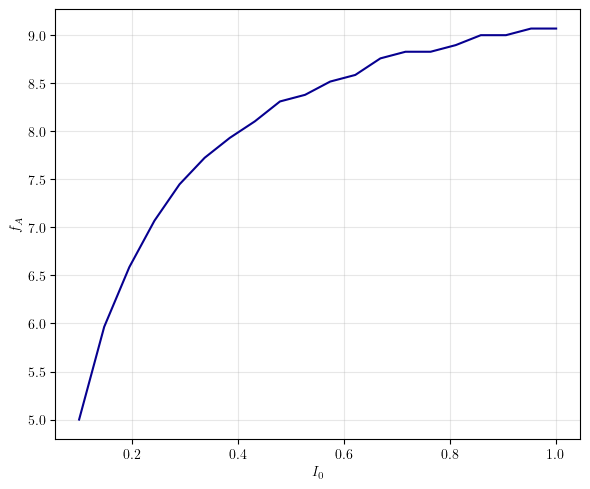

In [4]:
fig = plot.frA_I_curve(df_const_open)
fig.savefig(FIG_DIR / "fI_curve.pdf", bbox_inches="tight")

Free-running rate at I0=0.34: f0 = 7.72 Hz


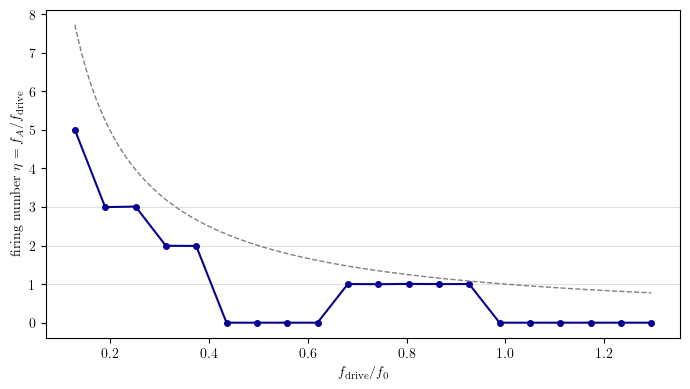

In [5]:
fig = plot.staircase(df_const_open, df_sin_open, df_const_open["I0"][5])
fig.savefig(FIG_DIR / "staircase.pdf", bbox_inches="tight")